#**PROBLEMA DE NEGOCIO**


---




Se trata de un algoritmo capaz de analizar las características de una propiedad -como comodidades, tamaño, ocupación del espacio en un período determinado- y sugerir al anfitrión un precio a cobrar por tarifas diarias que garantice ganancias en momentos de alta demanda.

#**1. Entendiendo el Problema**


---




In [116]:
import pandas as pd

In [117]:
datos = pd.read_json('datos_hosting.json')
datos.head()

,info_inmuebles
0,"{'evaluacion_general': '10.0', 'experiencia_lo..."
1,"{'evaluacion_general': '10.0', 'experiencia_lo..."
2,"{'evaluacion_general': '10.0', 'experiencia_lo..."
3,"{'evaluacion_general': '10.0', 'experiencia_lo..."
4,"{'evaluacion_general': '10.0', 'experiencia_lo..."


In [118]:
datos = pd.json_normalize(datos['info_inmuebles'])
datos.head()

,evaluacion_general,experiencia_local,max_hospedes,descripcion_local,descripcion_vecindad,cantidad_baños,cantidad_cuartos,cantidad_camas,modelo_cama,comodidades,cuota_deposito,cuota_limpieza,precio
0,10.0,--,1,[This clean and comfortable one bedroom sits r...,[Lower Queen Anne is near the Seattle Center (...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[Real Bed, Futon, Futon, Pull-out Sofa, Real B...","[{Internet,""Wireless Internet"",Kitchen,""Free P...","[$0, $0, $0, $0, $0, $350.00, $350.00, $350.00...","[$0, $0, $0, $20.00, $15.00, $28.00, $35.00, $...","[$110.00, $45.00, $55.00, $52.00, $85.00, $50...."
1,10.0,--,10,[Welcome to the heart of the 'Ballard Brewery ...,"[--, Capital Hill is the heart of Seattle, bor...","[2, 3, 2, 3, 3, 3, 2, 1, 2, 2, 2]","[3, 4, 2, 3, 3, 3, 3, 3, 3, 4, 3]","[5, 6, 8, 3, 3, 5, 4, 5, 6, 7, 4]","[Real Bed, Real Bed, Real Bed, Real Bed, Real ...","[{TV,Internet,""Wireless Internet"",Kitchen,""Fre...","[$500.00, $300.00, $0, $300.00, $300.00, $360....","[$125.00, $100.00, $85.00, $110.00, $110.00, $...","[$350.00, $300.00, $425.00, $300.00, $285.00, ..."
2,10.0,--,11,[New modern house built in 2013. Spectacular ...,[Upper Queen Anne is a charming neighborhood f...,[4],[5],[7],[Real Bed],"[{TV,""Cable TV"",Internet,""Wireless Internet"",""...","[$1,000.00]",[$300.00],[$975.00]
3,10.0,--,12,[Our NW style home is 3200+ sq ft with 3 level...,[The Views from our top floor! Wallingford ha...,"[3, 3, 3, 3, 3, 3, 3, 3]","[6, 6, 5, 5, 5, 5, 4, 4]","[6, 6, 7, 8, 7, 7, 6, 6]","[Real Bed, Real Bed, Real Bed, Real Bed, Real ...","[{Internet,""Wireless Internet"",Kitchen,""Free P...","[$500.00, $500.00, $500.00, $500.00, $500.00, ...","[$225.00, $300.00, $250.00, $250.00, $250.00, ...","[$490.00, $550.00, $350.00, $350.00, $350.00, ..."
4,10.0,--,14,"[Perfect for groups. 2 bedrooms, full bathroom...",[Safeway grocery store within walking distance...,"[2, 3]","[2, 6]","[3, 9]","[Real Bed, Real Bed]","[{TV,Internet,""Wireless Internet"",Kitchen,""Fre...","[$300.00, $2,000.00]","[$40.00, $150.00]","[$200.00, $545.00]"


In [119]:
columns=list(datos.columns)
columns

['evaluacion_general',
 'experiencia_local',
 'max_hospedes',
 'descripcion_local',
 'descripcion_vecindad',
 'cantidad_baños',
 'cantidad_cuartos',
 'cantidad_camas',
 'modelo_cama',
 'comodidades',
 'cuota_deposito',
 'cuota_limpieza',
 'precio']

In [120]:
datos=datos.explode(columns[3:])
datos

,evaluacion_general,experiencia_local,max_hospedes,descripcion_local,descripcion_vecindad,cantidad_baños,cantidad_cuartos,cantidad_camas,modelo_cama,comodidades,cuota_deposito,cuota_limpieza,precio
0,10.0,--,1,This clean and comfortable one bedroom sits ri...,Lower Queen Anne is near the Seattle Center (s...,1,1,1,Real Bed,"{Internet,""Wireless Internet"",Kitchen,""Free Pa...",$0,$0,$110.00
0,10.0,--,1,Our century old Upper Queen Anne house is loca...,"Upper Queen Anne is a really pleasant, unique ...",1,1,1,Futon,"{TV,Internet,""Wireless Internet"",Kitchen,""Free...",$0,$0,$45.00
0,10.0,--,1,Cozy room in two-bedroom apartment along the l...,The convenience of being in Seattle but on the...,1,1,1,Futon,"{TV,Internet,""Wireless Internet"",Kitchen,""Free...",$0,$0,$55.00
0,10.0,--,1,Very lovely and cozy room for one. Convenientl...,"Ballard is lovely, vibrant and one of the most...",1,1,1,Pull-out Sofa,"{Internet,""Wireless Internet"",Kitchen,""Free Pa...",$0,$20.00,$52.00
0,10.0,--,1,The “Studio at Mibbett Hollow' is in a Beautif...,--,1,1,1,Real Bed,"{""Wireless Internet"",Kitchen,""Free Parking on ...",$0,$15.00,$85.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,nan,--,8,Beautiful craftsman home in the historic Wedgw...,--,3,4,5,Real Bed,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A...","$1,000.00",$178.00,$299.00
68,nan,--,8,Located in a very easily accessible area of Se...,"Quiet, dead end street near I-5. The proximity...",2,4,4,Real Bed,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",$0,$99.00,$199.00
68,nan,--,8,This home is fully furnished and available wee...,--,1,3,4,Real Bed,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A...",$0,$0,$400.00
69,nan,--,9,This business-themed modern home features: *H...,Your hosts made Madison Valley their home when...,2,3,6,Real Bed,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A...","$1,000.00",$150.00,$250.00


In [121]:
#actualizamos el indice
datos.reset_index(inplace=True,drop=True)
datos.head()

,evaluacion_general,experiencia_local,max_hospedes,descripcion_local,descripcion_vecindad,cantidad_baños,cantidad_cuartos,cantidad_camas,modelo_cama,comodidades,cuota_deposito,cuota_limpieza,precio
0,10.0,--,1,This clean and comfortable one bedroom sits ri...,Lower Queen Anne is near the Seattle Center (s...,1,1,1,Real Bed,"{Internet,""Wireless Internet"",Kitchen,""Free Pa...",$0,$0,$110.00
1,10.0,--,1,Our century old Upper Queen Anne house is loca...,"Upper Queen Anne is a really pleasant, unique ...",1,1,1,Futon,"{TV,Internet,""Wireless Internet"",Kitchen,""Free...",$0,$0,$45.00
2,10.0,--,1,Cozy room in two-bedroom apartment along the l...,The convenience of being in Seattle but on the...,1,1,1,Futon,"{TV,Internet,""Wireless Internet"",Kitchen,""Free...",$0,$0,$55.00
3,10.0,--,1,Very lovely and cozy room for one. Convenientl...,"Ballard is lovely, vibrant and one of the most...",1,1,1,Pull-out Sofa,"{Internet,""Wireless Internet"",Kitchen,""Free Pa...",$0,$20.00,$52.00
4,10.0,--,1,The “Studio at Mibbett Hollow' is in a Beautif...,--,1,1,1,Real Bed,"{""Wireless Internet"",Kitchen,""Free Parking on ...",$0,$15.00,$85.00


In [122]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3818 entries, 0 to 3817
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   evaluacion_general    3818 non-null   object
 1   experiencia_local     3818 non-null   object
 2   max_hospedes          3818 non-null   object
 3   descripcion_local     3818 non-null   object
 4   descripcion_vecindad  3818 non-null   object
 5   cantidad_baños        3818 non-null   object
 6   cantidad_cuartos      3818 non-null   object
 7   cantidad_camas        3818 non-null   object
 8   modelo_cama           3818 non-null   object
 9   comodidades           3818 non-null   object
 10  cuota_deposito        3818 non-null   object
 11  cuota_limpieza        3818 non-null   object
 12  precio                3818 non-null   object
dtypes: object(13)
memory usage: 387.9+ KB


Vamos a cambiar el tipo de dato, object no es correcto, python lo utliza cuando no sabe bien que tipo de dato es

In [123]:
datos

,evaluacion_general,experiencia_local,max_hospedes,descripcion_local,descripcion_vecindad,cantidad_baños,cantidad_cuartos,cantidad_camas,modelo_cama,comodidades,cuota_deposito,cuota_limpieza,precio
0,10.0,--,1,This clean and comfortable one bedroom sits ri...,Lower Queen Anne is near the Seattle Center (s...,1,1,1,Real Bed,"{Internet,""Wireless Internet"",Kitchen,""Free Pa...",$0,$0,$110.00
1,10.0,--,1,Our century old Upper Queen Anne house is loca...,"Upper Queen Anne is a really pleasant, unique ...",1,1,1,Futon,"{TV,Internet,""Wireless Internet"",Kitchen,""Free...",$0,$0,$45.00
2,10.0,--,1,Cozy room in two-bedroom apartment along the l...,The convenience of being in Seattle but on the...,1,1,1,Futon,"{TV,Internet,""Wireless Internet"",Kitchen,""Free...",$0,$0,$55.00
3,10.0,--,1,Very lovely and cozy room for one. Convenientl...,"Ballard is lovely, vibrant and one of the most...",1,1,1,Pull-out Sofa,"{Internet,""Wireless Internet"",Kitchen,""Free Pa...",$0,$20.00,$52.00
4,10.0,--,1,The “Studio at Mibbett Hollow' is in a Beautif...,--,1,1,1,Real Bed,"{""Wireless Internet"",Kitchen,""Free Parking on ...",$0,$15.00,$85.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3813,nan,--,8,Beautiful craftsman home in the historic Wedgw...,--,3,4,5,Real Bed,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A...","$1,000.00",$178.00,$299.00
3814,nan,--,8,Located in a very easily accessible area of Se...,"Quiet, dead end street near I-5. The proximity...",2,4,4,Real Bed,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",$0,$99.00,$199.00
3815,nan,--,8,This home is fully furnished and available wee...,--,1,3,4,Real Bed,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A...",$0,$0,$400.00
3816,nan,--,9,This business-themed modern home features: *H...,Your hosts made Madison Valley their home when...,2,3,6,Real Bed,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A...","$1,000.00",$150.00,$250.00


In [124]:
import numpy as np

In [125]:
datos['max_hospedes']=datos['max_hospedes'].astype(np.int64)

In [126]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3818 entries, 0 to 3817
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   evaluacion_general    3818 non-null   object
 1   experiencia_local     3818 non-null   object
 2   max_hospedes          3818 non-null   int64 
 3   descripcion_local     3818 non-null   object
 4   descripcion_vecindad  3818 non-null   object
 5   cantidad_baños        3818 non-null   object
 6   cantidad_cuartos      3818 non-null   object
 7   cantidad_camas        3818 non-null   object
 8   modelo_cama           3818 non-null   object
 9   comodidades           3818 non-null   object
 10  cuota_deposito        3818 non-null   object
 11  cuota_limpieza        3818 non-null   object
 12  precio                3818 non-null   object
dtypes: int64(1), object(12)
memory usage: 387.9+ KB


In [127]:
colnumericas=['cantidad_baños','cantidad_cuartos','cantidad_camas']
datos[colnumericas]=datos[colnumericas].astype(np.int64)

In [128]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3818 entries, 0 to 3817
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   evaluacion_general    3818 non-null   object
 1   experiencia_local     3818 non-null   object
 2   max_hospedes          3818 non-null   int64 
 3   descripcion_local     3818 non-null   object
 4   descripcion_vecindad  3818 non-null   object
 5   cantidad_baños        3818 non-null   int64 
 6   cantidad_cuartos      3818 non-null   int64 
 7   cantidad_camas        3818 non-null   int64 
 8   modelo_cama           3818 non-null   object
 9   comodidades           3818 non-null   object
 10  cuota_deposito        3818 non-null   object
 11  cuota_limpieza        3818 non-null   object
 12  precio                3818 non-null   object
dtypes: int64(4), object(9)
memory usage: 387.9+ KB


In [129]:
datos['evaluacion_general']=datos['evaluacion_general'].astype(np.float64)

In [130]:
#quitamos el $ de las columnas de monedas
datos['precio']=datos['precio'].apply(lambda x : x.replace('$','').replace(',','').strip())
datos['precio']=datos['precio'].astype(np.float64)

In [131]:
datos[['cuota_deposito','cuota_limpieza']].applymap(lambda x : x.replace('$','').replace(',','').strip())


/tmp/ipython-input-3761871999.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  datos[['cuota_deposito','cuota_limpieza']].applymap(lambda x : x.replace('$','').replace(',','').strip())


,cuota_deposito,cuota_limpieza
0,0,0
1,0,0
2,0,0
3,0,20.00
4,0,15.00
...,...,...
3813,1000.00,178.00
3814,0,99.00
3815,0,0
3816,1000.00,150.00


In [132]:
datos[['cuota_deposito','cuota_limpieza']]=datos[['cuota_deposito','cuota_limpieza']].applymap(lambda x : x.replace('$','').replace(',','').strip())
datos[['cuota_deposito','cuota_limpieza']]=datos[['cuota_deposito','cuota_limpieza']].astype(np.float64)

/tmp/ipython-input-3172089297.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  datos[['cuota_deposito','cuota_limpieza']]=datos[['cuota_deposito','cuota_limpieza']].applymap(lambda x : x.replace('$','').replace(',','').strip())


In [133]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3818 entries, 0 to 3817
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   evaluacion_general    3162 non-null   float64
 1   experiencia_local     3818 non-null   object 
 2   max_hospedes          3818 non-null   int64  
 3   descripcion_local     3818 non-null   object 
 4   descripcion_vecindad  3818 non-null   object 
 5   cantidad_baños        3818 non-null   int64  
 6   cantidad_cuartos      3818 non-null   int64  
 7   cantidad_camas        3818 non-null   int64  
 8   modelo_cama           3818 non-null   object 
 9   comodidades           3818 non-null   object 
 10  cuota_deposito        3818 non-null   float64
 11  cuota_limpieza        3818 non-null   float64
 12  precio                3818 non-null   float64
dtypes: float64(4), int64(4), object(5)
memory usage: 387.9+ KB


DATOS DE TEXTO

In [134]:
datos['descripcion_local']=datos['descripcion_local'].str.lower()
datos['descripcion_vecindad']=datos['descripcion_vecindad'].str.lower()
datos['modelo_cama']=datos['modelo_cama'].str.lower()
datos['comodidades']=datos['comodidades'].str.lower()

In [135]:
#remplazar caracteres especiales por nada, remplaza todo lo que no es letra de la a-z numeros de 0-9 - y '
datos['descripcion_local']=datos['descripcion_local'].str.replace('[^a-zA-Z0-9\-\']',' ',regex=True)

<>:2: SyntaxWarning: invalid escape sequence '\-'
<>:2: SyntaxWarning: invalid escape sequence '\-'
/tmp/ipython-input-559975268.py:2: SyntaxWarning: invalid escape sequence '\-'
  datos['descripcion_local']=datos['descripcion_local'].str.replace('[^a-zA-Z0-9\-\']',' ',regex=True)


In [136]:
#remplaza los - que no tienen un caracter inmedatamente antes o despues
datos['descripcion_local']=datos['descripcion_local'].str.replace('(?<!\w)-(?!\w)' ,' ' ,regex=True)

<>:2: SyntaxWarning: invalid escape sequence '\w'
<>:2: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipython-input-888518544.py:2: SyntaxWarning: invalid escape sequence '\w'
  datos['descripcion_local']=datos['descripcion_local'].str.replace('(?<!\w)-(?!\w)' ,' ' ,regex=True)


In [137]:
datos['descripcion_local'].sample(10)

,descripcion_local
3256,spacious basement one-bed bath apartment avail...
1355,our home is cozy with lots of natural light t...
2629,the building is right on the border of capitol...
1175,located in seattle's eclectic wallingford neig...
777,beautiful cozy home with a very small footpri...
138,a story book wagon that you can sleep in ma...
2021,modern 4 beds 3 queens 1 twin 3 bedrooms ...
2461,a perfectly located home within a home in desi...
3218,this is a modern fully-furnished studio apartm...
3555,i live here with my 3 y o daughter my apartm...


Regex (o expresión regular) es una secuencia de caracteres que define un patrón de búsqueda en un texto. Es una herramienta poderosa y versátil que le permite buscar, reemplazar y manipular patrones de texto de manera eficiente.

In [138]:
datos['descripcion_local']=datos['descripcion_local'].str.split()
datos.head()

,evaluacion_general,experiencia_local,max_hospedes,descripcion_local,descripcion_vecindad,cantidad_baños,cantidad_cuartos,cantidad_camas,modelo_cama,comodidades,cuota_deposito,cuota_limpieza,precio
0,10.0,--,1,"[this, clean, and, comfortable, one, bedroom, ...",lower queen anne is near the seattle center (s...,1,1,1,real bed,"{internet,""wireless internet"",kitchen,""free pa...",0.0,0.0,110.0
1,10.0,--,1,"[our, century, old, upper, queen, anne, house,...","upper queen anne is a really pleasant, unique ...",1,1,1,futon,"{tv,internet,""wireless internet"",kitchen,""free...",0.0,0.0,45.0
2,10.0,--,1,"[cozy, room, in, two-bedroom, apartment, along...",the convenience of being in seattle but on the...,1,1,1,futon,"{tv,internet,""wireless internet"",kitchen,""free...",0.0,0.0,55.0
3,10.0,--,1,"[very, lovely, and, cozy, room, for, one, conv...","ballard is lovely, vibrant and one of the most...",1,1,1,pull-out sofa,"{internet,""wireless internet"",kitchen,""free pa...",0.0,20.0,52.0
4,10.0,--,1,"[the, studio, at, mibbett, hollow', is, in, a,...",--,1,1,1,real bed,"{""wireless internet"",kitchen,""free parking on ...",0.0,15.0,85.0


In [139]:
#remplazamos las llaves y comillas de la columna comodidades y lo hacemos una lista separando por ,
datos['comodidades']=datos['comodidades'].str.replace('\{|}|\"' ,'' ,regex=True)
datos['comodidades']=datos['comodidades'].str.split(',')
datos.head()

<>:2: SyntaxWarning: invalid escape sequence '\{'
<>:2: SyntaxWarning: invalid escape sequence '\{'
/tmp/ipython-input-3089664340.py:2: SyntaxWarning: invalid escape sequence '\{'
  datos['comodidades']=datos['comodidades'].str.replace('\{|}|\"' ,'' ,regex=True)


,evaluacion_general,experiencia_local,max_hospedes,descripcion_local,descripcion_vecindad,cantidad_baños,cantidad_cuartos,cantidad_camas,modelo_cama,comodidades,cuota_deposito,cuota_limpieza,precio
0,10.0,--,1,"[this, clean, and, comfortable, one, bedroom, ...",lower queen anne is near the seattle center (s...,1,1,1,real bed,"[internet, wireless internet, kitchen, free pa...",0.0,0.0,110.0
1,10.0,--,1,"[our, century, old, upper, queen, anne, house,...","upper queen anne is a really pleasant, unique ...",1,1,1,futon,"[tv, internet, wireless internet, kitchen, fre...",0.0,0.0,45.0
2,10.0,--,1,"[cozy, room, in, two-bedroom, apartment, along...",the convenience of being in seattle but on the...,1,1,1,futon,"[tv, internet, wireless internet, kitchen, fre...",0.0,0.0,55.0
3,10.0,--,1,"[very, lovely, and, cozy, room, for, one, conv...","ballard is lovely, vibrant and one of the most...",1,1,1,pull-out sofa,"[internet, wireless internet, kitchen, free pa...",0.0,20.0,52.0
4,10.0,--,1,"[the, studio, at, mibbett, hollow', is, in, a,...",--,1,1,1,real bed,"[wireless internet, kitchen, free parking on p...",0.0,15.0,85.0


In [140]:
datos['descripcion_vecindad'] = datos['descripcion_vecindad'].str.replace('[^a-zA-Z0-9\-\']', ' ', regex=True)
datos['descripcion_vecindad'] = datos['descripcion_vecindad'].str.replace('(?<!\w)-(?!\w)', '', regex=True)
# Transformamos el texto en lista, formando el token
datos['descripcion_vecindad'] = datos['descripcion_vecindad'].str.split()
datos.head()

<>:1: SyntaxWarning: invalid escape sequence '\-'
<>:2: SyntaxWarning: invalid escape sequence '\w'
<>:1: SyntaxWarning: invalid escape sequence '\-'
<>:2: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipython-input-2324804390.py:1: SyntaxWarning: invalid escape sequence '\-'
  datos['descripcion_vecindad'] = datos['descripcion_vecindad'].str.replace('[^a-zA-Z0-9\-\']', ' ', regex=True)
/tmp/ipython-input-2324804390.py:2: SyntaxWarning: invalid escape sequence '\w'
  datos['descripcion_vecindad'] = datos['descripcion_vecindad'].str.replace('(?<!\w)-(?!\w)', '', regex=True)


,evaluacion_general,experiencia_local,max_hospedes,descripcion_local,descripcion_vecindad,cantidad_baños,cantidad_cuartos,cantidad_camas,modelo_cama,comodidades,cuota_deposito,cuota_limpieza,precio
0,10.0,--,1,"[this, clean, and, comfortable, one, bedroom, ...","[lower, queen, anne, is, near, the, seattle, c...",1,1,1,real bed,"[internet, wireless internet, kitchen, free pa...",0.0,0.0,110.0
1,10.0,--,1,"[our, century, old, upper, queen, anne, house,...","[upper, queen, anne, is, a, really, pleasant, ...",1,1,1,futon,"[tv, internet, wireless internet, kitchen, fre...",0.0,0.0,45.0
2,10.0,--,1,"[cozy, room, in, two-bedroom, apartment, along...","[the, convenience, of, being, in, seattle, but...",1,1,1,futon,"[tv, internet, wireless internet, kitchen, fre...",0.0,0.0,55.0
3,10.0,--,1,"[very, lovely, and, cozy, room, for, one, conv...","[ballard, is, lovely, vibrant, and, one, of, t...",1,1,1,pull-out sofa,"[internet, wireless internet, kitchen, free pa...",0.0,20.0,52.0
4,10.0,--,1,"[the, studio, at, mibbett, hollow', is, in, a,...",[],1,1,1,real bed,"[wireless internet, kitchen, free parking on p...",0.0,15.0,85.0


La clase datetime es un tipo de datos que representa una fecha y hora específicas en Python. Permite trabajar y manipular datos de año, mes, día, hora, minuto, segundo y microsegundo, así como días de la semana, como lunes, martes, miércoles, etc.

In [141]:
dt_data=pd.read_json('inmuebles_disponibles.json')
dt_data.head()

,id,fecha,lugar_disponible,precio
0,857,2016-01-04,False,None
1,857,2016-01-05,False,None
2,857,2016-01-06,False,None
3,857,2016-01-07,False,None
4,857,2016-01-08,False,None


In [142]:
dt_data['fecha']=pd.to_datetime(dt_data['fecha'])
dt_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 365000 entries, 0 to 364999
Data columns (total 4 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id                365000 non-null  int64         
 1   fecha             365000 non-null  datetime64[ns]
 2   lugar_disponible  365000 non-null  bool          
 3   precio            270547 non-null  object        
dtypes: bool(1), datetime64[ns](1), int64(1), object(1)
memory usage: 11.5+ MB


In [143]:
#dt considera todo en el formato datetime, strftime le da el formato que queramos
dt_data['fecha'].dt.strftime('%Y-%m')

,fecha
0,2016-01
1,2016-01
2,2016-01
3,2016-01
4,2016-01
...,...
364995,2016-12
364996,2016-12
364997,2016-12
364998,2017-01


Suma de todos los inmuebles disponibles por mes

In [144]:
dt_data.groupby(dt_data['fecha'].dt.strftime('%Y-%m'))['lugar_disponible'].sum()

,lugar_disponible
fecha,
2016-01,16543
2016-02,20128
2016-03,23357
2016-04,22597
2016-05,23842
2016-06,23651
2016-07,22329
2016-08,22529
2016-09,22471


# SELECCION Y AGRUPAMIENTO DE DATOS

Analizaremos datos de emisiones de gases de efecto invernadero y crearemos tablas y visualizaciones para entender los datos y generar insigths

In [145]:
emision_gases=pd.read_excel('1-SEEG10_GERAL-BR_UF_2022.10.27-FINAL-SITE.xlsx',sheet_name='GEE Estados')
emision_gases

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Emissão / Remoção / Bunker,Gás,Estado,Atividade Econômica,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Processos Industriais,Indústria Química,Produção de ABS,NaN,NaN,NaN,Emissão,COVNM (t),SP,OUTRA_IND,...,897.600,897.600,897.600,897.600,897.600,897.600,897.600,897.600,8.976000e+02,897.600
1,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,N2O (t),SP,OUTRA_IND,...,130.000,130.000,130.000,130.000,130.000,130.000,130.000,130.000,1.300000e+02,130.000
2,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,CO (t),SP,OUTRA_IND,...,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576,1.380576e+03,1380.576
3,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,NOx (t),SP,OUTRA_IND,...,431.430,431.430,431.430,431.430,431.430,431.430,431.430,431.430,4.314300e+02,431.430
4,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,CO2e (t) GWP-AR2,SP,OUTRA_IND,...,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000,4.030000e+04,40300.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103307,Mudança de Uso da Terra e Floresta,Queimadas Não Associadas a Desmatamento,Pantanal,NaN,NaN,NaN,Emissão NCI,CO2e (t) GTP-AR6,BR,NaN,...,2731963.400,1091033.900,853275.300,1003731.400,1615000.600,1552258.800,216231.900,2805297.300,9.659261e+06,0.000
103308,Mudança de Uso da Terra e Floresta,Queimadas Não Associadas a Desmatamento,Pantanal,NaN,NaN,NaN,Emissão NCI,CO2e (t) GWP-AR2,BR,NaN,...,2921341.000,1144504.000,896685.000,1074717.000,1763431.000,1706030.000,252599.000,3105007.000,1.053571e+07,0.000
103309,Mudança de Uso da Terra e Floresta,Queimadas Não Associadas a Desmatamento,Pantanal,NaN,NaN,NaN,Emissão NCI,CO2e (t) GWP-AR4,BR,NaN,...,2950049.000,1151848.000,902209.000,1084073.000,1782863.000,1726958.000,257507.000,3147567.000,1.067568e+07,0.000
103310,Mudança de Uso da Terra e Floresta,Queimadas Não Associadas a Desmatamento,Pantanal,NaN,NaN,NaN,Emissão NCI,CO2e (t) GWP-AR5,BR,NaN,...,2957780.000,1152868.000,902368.000,1084826.000,1784237.000,1729598.000,258068.000,3155415.000,1.072232e+07,0.000


In [146]:
emision_gases.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103312 entries, 0 to 103311
Data columns (total 63 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Nível 1 - Setor             103312 non-null  object 
 1   Nível 2                     103312 non-null  object 
 2   Nível 3                     103253 non-null  object 
 3   Nível 4                     90920 non-null   object 
 4   Nível 5                     100788 non-null  object 
 5   Nível 6                     97691 non-null   object 
 6   Emissão / Remoção / Bunker  103312 non-null  object 
 7   Gás                         103312 non-null  object 
 8   Estado                      97374 non-null   object 
 9   Atividade Econômica         102076 non-null  object 
 10  Produto                     37413 non-null   object 
 11  1970                        103312 non-null  float64
 12  1971                        103312 non-null  float64
 13  1972          

Remociones son datos de retirada de gases, que es lo contrario a emision

NCI son los datos no iluidos en el inventario nacional

Bunkers son emisiones del transporte maritimo y aero inernacional por lo tanto no pertenecen a las emisiones de los estados


In [147]:
emision_gases['Emissão / Remoção / Bunker'].unique()

array(['Emissão', 'Emissão NCI', 'Remoção NCI', 'Bunker', 'Remoção'],
      dtype=object)

In [148]:
emision_gases[emision_gases['Emissão / Remoção / Bunker'].isin(['Remoção NCI','Remoção'])]

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Emissão / Remoção / Bunker,Gás,Estado,Atividade Econômica,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
23520,Agropecuária,Solos Manejados,Diretas,Variação dos Estoques de Carbono no Solo,Vegetal,Pastagem Bem Manejada,Remoção NCI,CO2 (t),RO,PEC,...,-1.434540e+07,-1.499358e+07,-1.543196e+07,-1.567070e+07,-1.630063e+07,-1.702215e+07,-1.740074e+07,-1.771914e+07,-1.767632e+07,-1.838895e+07
23521,Agropecuária,Solos Manejados,Diretas,Variação dos Estoques de Carbono no Solo,Vegetal,Pastagem Bem Manejada,Remoção NCI,CO2 (t),AC,PEC,...,-5.382949e+06,-5.524659e+06,-5.632429e+06,-5.765030e+06,-5.867354e+06,-5.942076e+06,-6.022000e+06,-6.002147e+06,-6.035591e+06,-6.459079e+06
23522,Agropecuária,Solos Manejados,Diretas,Variação dos Estoques de Carbono no Solo,Vegetal,Pastagem Bem Manejada,Remoção NCI,CO2 (t),AM,PEC,...,-3.450455e+06,-3.540294e+06,-3.545724e+06,-3.924546e+06,-4.626541e+06,-4.874199e+06,-4.849173e+06,-4.959540e+06,-5.106806e+06,-5.809814e+06
23523,Agropecuária,Solos Manejados,Diretas,Variação dos Estoques de Carbono no Solo,Vegetal,Pastagem Bem Manejada,Remoção NCI,CO2 (t),RR,PEC,...,-1.260166e+06,-1.261895e+06,-1.371664e+06,-1.501452e+06,-1.507705e+06,-1.509919e+06,-1.609826e+06,-1.616980e+06,-1.518397e+06,-1.926000e+06
23524,Agropecuária,Solos Manejados,Diretas,Variação dos Estoques de Carbono no Solo,Vegetal,Pastagem Bem Manejada,Remoção NCI,CO2 (t),PA,PEC,...,-3.429279e+07,-3.317185e+07,-3.281628e+07,-3.350720e+07,-3.557183e+07,-3.755308e+07,-4.134614e+07,-4.229403e+07,-4.275448e+07,-4.443440e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102751,Mudança de Uso da Terra e Floresta,Remoção por Vegetação Secundária,Pantanal,em Área Protegida,Vegetação nativa estável,Vegetação não florestal secundária -- Vegetaçã...,Remoção,CO2e (t) GWP-AR4,MS,AGROPEC,...,-7.513000e+04,-7.911900e+04,-8.695900e+04,-9.201400e+04,-9.149400e+04,-9.630200e+04,-9.202000e+04,-9.762300e+04,-1.015020e+05,-1.008910e+05
102752,Mudança de Uso da Terra e Floresta,Remoção por Vegetação Secundária,Pantanal,em Área Protegida,Vegetação nativa estável,Vegetação não florestal secundária -- Vegetaçã...,Remoção,CO2e (t) GWP-AR5,MT,AGROPEC,...,-9.523000e+03,-9.667000e+03,-1.000300e+04,-1.024200e+04,-1.027200e+04,-1.019100e+04,-1.046900e+04,-1.090400e+04,-1.104100e+04,-1.109500e+04
102753,Mudança de Uso da Terra e Floresta,Remoção por Vegetação Secundária,Pantanal,em Área Protegida,Vegetação nativa estável,Vegetação não florestal secundária -- Vegetaçã...,Remoção,CO2e (t) GWP-AR5,MS,AGROPEC,...,-7.513000e+04,-7.911900e+04,-8.695900e+04,-9.201400e+04,-9.149400e+04,-9.630200e+04,-9.202000e+04,-9.762300e+04,-1.015020e+05,-1.008910e+05
102754,Mudança de Uso da Terra e Floresta,Remoção por Vegetação Secundária,Pantanal,em Área Protegida,Vegetação nativa estável,Vegetação não florestal secundária -- Vegetaçã...,Remoção,CO2e (t) GWP-AR6,MT,AGROPEC,...,-9.523000e+03,-9.667000e+03,-1.000300e+04,-1.024200e+04,-1.027200e+04,-1.019100e+04,-1.046900e+04,-1.090400e+04,-1.104100e+04,-1.109500e+04


In [149]:
#vemos solo los valores numericos
emision_gases.loc[emision_gases['Emissão / Remoção / Bunker'].isin(['Remoção NCI','Remoção']),1970:2021]

,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
23520,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.434540e+07,-1.499358e+07,-1.543196e+07,-1.567070e+07,-1.630063e+07,-1.702215e+07,-1.740074e+07,-1.771914e+07,-1.767632e+07,-1.838895e+07
23521,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-5.382949e+06,-5.524659e+06,-5.632429e+06,-5.765030e+06,-5.867354e+06,-5.942076e+06,-6.022000e+06,-6.002147e+06,-6.035591e+06,-6.459079e+06
23522,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-3.450455e+06,-3.540294e+06,-3.545724e+06,-3.924546e+06,-4.626541e+06,-4.874199e+06,-4.849173e+06,-4.959540e+06,-5.106806e+06,-5.809814e+06
23523,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.260166e+06,-1.261895e+06,-1.371664e+06,-1.501452e+06,-1.507705e+06,-1.509919e+06,-1.609826e+06,-1.616980e+06,-1.518397e+06,-1.926000e+06
23524,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-3.429279e+07,-3.317185e+07,-3.281628e+07,-3.350720e+07,-3.557183e+07,-3.755308e+07,-4.134614e+07,-4.229403e+07,-4.275448e+07,-4.443440e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102751,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-7.513000e+04,-7.911900e+04,-8.695900e+04,-9.201400e+04,-9.149400e+04,-9.630200e+04,-9.202000e+04,-9.762300e+04,-1.015020e+05,-1.008910e+05
102752,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-9.523000e+03,-9.667000e+03,-1.000300e+04,-1.024200e+04,-1.027200e+04,-1.019100e+04,-1.046900e+04,-1.090400e+04,-1.104100e+04,-1.109500e+04
102753,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-7.513000e+04,-7.911900e+04,-8.695900e+04,-9.201400e+04,-9.149400e+04,-9.630200e+04,-9.202000e+04,-9.762300e+04,-1.015020e+05,-1.008910e+05
102754,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-9.523000e+03,-9.667000e+03,-1.000300e+04,-1.024200e+04,-1.027200e+04,-1.019100e+04,-1.046900e+04,-1.090400e+04,-1.104100e+04,-1.109500e+04


In [150]:
emision_gases.loc[emision_gases['Emissão / Remoção / Bunker'].isin(['Remoção NCI','Remoção']),1970:2021].max()

,0
1970,0.0
1971,0.0
1972,0.0
1973,0.0
1974,0.0
1975,0.0
1976,0.0
1977,0.0
1978,0.0
1979,0.0


In [151]:
#loc permite filtrar por fila y luego por columna
emision_gases.loc[emision_gases['Emissão / Remoção / Bunker']=='Bunker','Estado']

,Estado
67365,NaN
67366,NaN
67367,NaN
67368,NaN
67369,NaN
67370,NaN
67371,NaN
67372,NaN
67373,NaN
67374,NaN


In [152]:
emision_gases=emision_gases[emision_gases['Emissão / Remoção / Bunker']=='Emissão']
emision_gases

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Emissão / Remoção / Bunker,Gás,Estado,Atividade Econômica,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Processos Industriais,Indústria Química,Produção de ABS,NaN,NaN,NaN,Emissão,COVNM (t),SP,OUTRA_IND,...,897.600000,897.600000,897.600000,897.600000,897.600000,897.600000,897.600000,897.600,897.600,897.600
1,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,N2O (t),SP,OUTRA_IND,...,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000,130.000,130.000
2,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,CO (t),SP,OUTRA_IND,...,1380.576000,1380.576000,1380.576000,1380.576000,1380.576000,1380.576000,1380.576000,1380.576,1380.576,1380.576
3,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,NOx (t),SP,OUTRA_IND,...,431.430000,431.430000,431.430000,431.430000,431.430000,431.430000,431.430000,431.430,431.430,431.430
4,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,CO2e (t) GWP-AR2,SP,OUTRA_IND,...,40300.000000,40300.000000,40300.000000,40300.000000,40300.000000,40300.000000,40300.000000,40300.000,40300.000,40300.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103241,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,Emissão,CO2e (t) GWP-AR5,MS,AGROPEC,...,436935.000000,500067.000000,440030.000000,365272.000000,438422.000000,391113.000000,411738.000000,437039.000,871393.000,1004191.000
103242,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,Emissão,CO2e (t) GWP-AR6,MT,AGROPEC,...,126806.000000,127558.000000,193758.000000,164585.000000,234509.000000,190412.000000,162919.000000,186091.000,368149.000,443120.000
103243,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,Emissão,CO2e (t) GWP-AR6,MS,AGROPEC,...,439524.000000,502908.000000,442493.000000,367116.000000,440798.000000,393101.000000,413749.000000,439526.000,876637.000,1009968.000
103244,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,Emissão,N2O (t),MT,AGROPEC,...,108.441090,109.811199,166.680103,141.442361,201.556097,162.932751,137.219684,158.000,314.000,479.000


Para eliminar datos de un DataFrame, podemos usar el método drop(). Este métodos permite la eliminación tanto de filas como de columnas, utilizando los respectivos parámetros index y columns o del parámetro axis que indican los índices (filas) con valor 0 y columnas con valor 1.

Este método puede eliminar más de un elemento a la vez si se los pasa como una lista y, como resultado, genera una copia del DataFrame con las columnas eliminadas. El DataFrame original no se modifica y si deseas conservar los cambios debes almacenar la copia en la misma variable o usar el parámetro inplace=True.

In [153]:
emision_gases=emision_gases.drop(columns='Emissão / Remoção / Bunker')

##Agrupando los datos
Vamos a cambiar el formato del dtaframe de wide a long

In [154]:
emision_gases.loc[:,'Nível 1 - Setor':'Produto'].columns

Index(['Nível 1 - Setor', 'Nível 2', 'Nível 3', 'Nível 4', 'Nível 5',
       'Nível 6', 'Gás', 'Estado', 'Atividade Econômica', 'Produto'],
      dtype='object')

In [155]:
columnas_info=list(emision_gases.loc[:,'Nível 1 - Setor':'Produto'].columns)
columnas_info

['Nível 1 - Setor',
 'Nível 2',
 'Nível 3',
 'Nível 4',
 'Nível 5',
 'Nível 6',
 'Gás',
 'Estado',
 'Atividade Econômica',
 'Produto']

In [156]:
columnas_año=list(emision_gases.loc[:,1970:2021].columns)
columnas_año

[1970,
 1971,
 1972,
 1973,
 1974,
 1975,
 1976,
 1977,
 1978,
 1979,
 1980,
 1981,
 1982,
 1983,
 1984,
 1985,
 1986,
 1987,
 1988,
 1989,
 1990,
 1991,
 1992,
 1993,
 1994,
 1995,
 1996,
 1997,
 1998,
 1999,
 2000,
 2001,
 2002,
 2003,
 2004,
 2005,
 2006,
 2007,
 2008,
 2009,
 2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2020,
 2021]

Utilizamos el metodo melt() para cambiar de un formato wide a un forato long

El parámetro id_vars se utiliza para identificar los nombres de las columnas que se mantendrán en el momento de la transformación. El parámetro value_vars se utiliza para identificar las columnas que se transformarán en las columnas principales del formato long, una que contiene las categorías con los nombres de las columnas y la otra que contiene los valores. El parámetro var_name se utiliza para nombrar la columna que contiene las categorías y el parámetro value_name para nombrar la columna con los valores numéricos.

In [157]:
emision_gases.melt(id_vars=columnas_info,value_vars=columnas_año,var_name='Año',value_name='Emision')

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Gás,Estado,Atividade Econômica,Produto,Año,Emision
0,Processos Industriais,Indústria Química,Produção de ABS,NaN,NaN,NaN,COVNM (t),SP,OUTRA_IND,NaN,1970,0.0
1,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,N2O (t),SP,OUTRA_IND,NaN,1970,6210.0
2,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,CO (t),SP,OUTRA_IND,NaN,1970,368.0
3,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,NOx (t),SP,OUTRA_IND,NaN,1970,115.0
4,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,CO2e (t) GWP-AR2,SP,OUTRA_IND,NaN,1970,1925100.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4926891,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR5,MS,AGROPEC,NaN,2021,1004191.0
4926892,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR6,MT,AGROPEC,NaN,2021,443120.0
4926893,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR6,MS,AGROPEC,NaN,2021,1009968.0
4926894,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,N2O (t),MT,AGROPEC,NaN,2021,479.0


In [158]:
emisiones_por_año=emision_gases.melt(id_vars=columnas_info,value_vars=columnas_año,var_name='Año',value_name='Emision')

In [159]:
emisiones_por_año.groupby('Gás').get_group('CO2 (t)')

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Gás,Estado,Atividade Econômica,Produto,Año,Emision
18,Processos Industriais,Indústria Química,Produção de Acrilonitrila,NaN,NaN,NaN,CO2 (t),BA,OUTRA_IND,NaN,1970,0.000000
23,Processos Industriais,Indústria Química,Produção de Amônia,NaN,NaN,NaN,CO2 (t),RJ,OUTRA_IND,NaN,1970,0.000000
26,Processos Industriais,Indústria Química,Produção de Amônia,NaN,NaN,NaN,CO2 (t),MG,OUTRA_IND,NaN,1970,0.000000
29,Processos Industriais,Indústria Química,Produção de Amônia,NaN,NaN,NaN,CO2 (t),BA,OUTRA_IND,NaN,1970,10742.465792
32,Processos Industriais,Indústria Química,Produção de Amônia,NaN,NaN,NaN,CO2 (t),SE,OUTRA_IND,NaN,1970,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
4926255,Mudança de Uso da Terra e Floresta,Alterações de Uso da Terra,Pantanal,em Área Protegida,Outras Mudanças de uso da terra,Uso agropecuário -- Uso agropecuário,CO2 (t),MS,AGROPEC,NaN,2021,0.000000
4926272,Mudança de Uso da Terra e Floresta,Alterações de Uso da Terra,Pantanal,em Área Protegida,Regeneração,Uso agropecuário -- Floresta secundária,CO2 (t),MT,AGROPEC,NaN,2021,374.000000
4926273,Mudança de Uso da Terra e Floresta,Alterações de Uso da Terra,Pantanal,em Área Protegida,Regeneração,Uso agropecuário -- Floresta secundária,CO2 (t),MS,AGROPEC,NaN,2021,8613.000000
4926290,Mudança de Uso da Terra e Floresta,Alterações de Uso da Terra,Pantanal,em Área Protegida,Regeneração,Uso agropecuário -- Vegetação não florestal se...,CO2 (t),MT,AGROPEC,NaN,2021,934.000000


In [160]:
emisiones_por_año.groupby('Gás').sum(numeric_only=True)

,Emision
Gás,
C2F6 (t),5.765018e+02
CF4 (t),7.135481e+03
CH4 (t),7.949268e+08
CO (t),5.111531e+08
CO2 (t),5.324636e+10
CO2e (t) GTP-AR2,6.344612e+10
CO2e (t) GTP-AR4,6.344612e+10
CO2e (t) GTP-AR5,6.182200e+10
CO2e (t) GTP-AR6,6.247859e+10


In [161]:
emision_por_gas=emisiones_por_año.groupby('Gás').sum(numeric_only=True).sort_values('Emision', ascending=False)

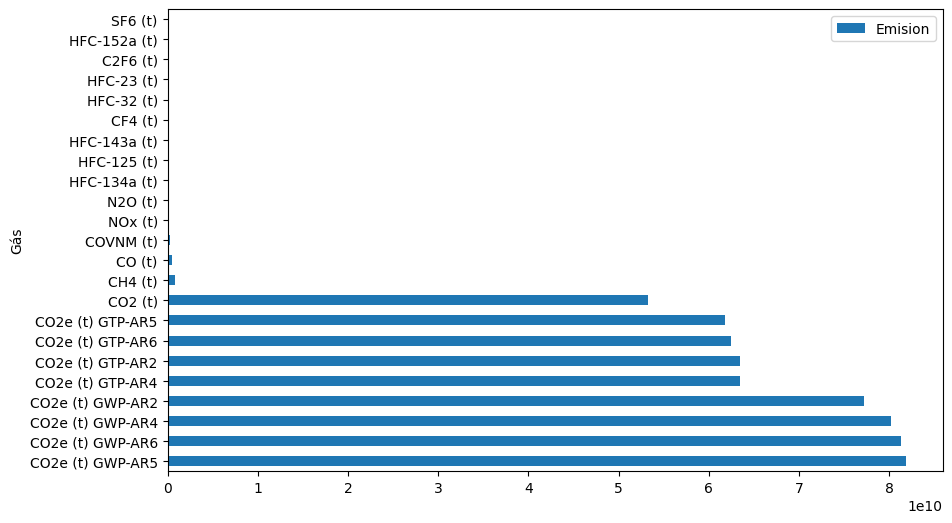

In [162]:
emision_por_gas.plot(kind='barh',figsize=(10,6));

In [163]:
emision_por_gas.iloc[0:9]

,Emision
Gás,
CO2e (t) GWP-AR5,8.181375e+10
CO2e (t) GWP-AR6,8.132316e+10
CO2e (t) GWP-AR4,8.015921e+10
CO2e (t) GWP-AR2,7.720596e+10
CO2e (t) GTP-AR4,6.344612e+10
CO2e (t) GTP-AR2,6.344612e+10
CO2e (t) GTP-AR6,6.247859e+10
CO2e (t) GTP-AR5,6.182200e+10
CO2 (t),5.324636e+10


In [164]:
emision_por_gas.iloc[0:9].sum()/emision_por_gas.sum()*100

,0
Emision,99.736253


In [165]:
print(f'Las emisiones de CO2 corresponen a {float(emision_por_gas.iloc[0:9].sum()/emision_por_gas.sum()*100):.2f}% de as emisiones totales de gases de efecto invernadero en brasil de 1970 a 2021')

Las emisiones de CO2 corresponen a 99.74% de as emisiones totales de gases de efecto invernadero en brasil de 1970 a 2021


/tmp/ipython-input-3046714577.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print(f'Las emisiones de CO2 corresponen a {float(emision_por_gas.iloc[0:9].sum()/emision_por_gas.sum()*100):.2f}% de as emisiones totales de gases de efecto invernadero en brasil de 1970 a 2021')


¿cuales son los sectores mas contaminantes por cada gas?

In [166]:
gas_por_sector=emisiones_por_año.groupby(['Gás','Nível 1 - Setor']).sum(numeric_only=True)
gas_por_sector

Emision
Gás      Nível 1 - Setor                                 
C2F6 (t) Processos Industriais               5.765018e+02
CF4 (t)  Processos Industriais               7.135481e+03
CH4 (t)  Agropecuária                        5.928481e+08
         Energia                             3.429034e+07
         Mudança de Uso da Terra e Floresta  8.662166e+07
...                                                   ...
N2O (t)  Resíduos                            2.764127e+05
NOx (t)  Agropecuária                        2.602719e+06
         Energia                             9.361215e+07
         Processos Industriais               3.546360e+06
SF6 (t)  Processos Industriais               4.705800e+02

[72 rows x 1 columns]

para descubir el sector que emite mayor cantidad de CO2 podemos realizar una seleccion especifica de gas mediante el metodo cross section xs() esxtrayendo de esto el valof maximo y el indice maximo con los metodos max() y idmax()

In [167]:
gas_por_sector.xs('CO2 (t)',level=0)

,Emision
Nível 1 - Setor,
Agropecuária,5.411750e+08
Energia,1.261352e+10
Mudança de Uso da Terra e Floresta,3.733930e+10
Processos Industriais,2.729603e+09
Resíduos,2.276264e+07


In [168]:
gas_por_sector.xs(('CO2 (t)','Mudança de Uso da Terra e Floresta'),level=[0,1])

,,Emision
Gás,Nível 1 - Setor,
CO2 (t),Mudança de Uso da Terra e Floresta,3.733930e+10


In [169]:
gas_por_sector.xs('CO2 (t)',level=0).max()

,0
Emision,3.733930e+10


In [170]:
gas_por_sector.xs('CO2 (t)',level=0).idxmax()

,0
Emision,Mudança de Uso da Terra e Floresta


Explorando groupby con idmax

In [171]:
gas_por_sector.groupby(level=0).idxmax()

,Emision
Gás,
C2F6 (t),"(C2F6 (t), Processos Industriais)"
CF4 (t),"(CF4 (t), Processos Industriais)"
CH4 (t),"(CH4 (t), Agropecuária)"
CO (t),"(CO (t), Energia)"
CO2 (t),"(CO2 (t), Mudança de Uso da Terra e Floresta)"
CO2e (t) GTP-AR2,"(CO2e (t) GTP-AR2, Mudança de Uso da Terra e F..."
CO2e (t) GTP-AR4,"(CO2e (t) GTP-AR4, Mudança de Uso da Terra e F..."
CO2e (t) GTP-AR5,"(CO2e (t) GTP-AR5, Mudança de Uso da Terra e F..."
CO2e (t) GTP-AR6,"(CO2e (t) GTP-AR6, Mudança de Uso da Terra e F..."


In [172]:
gas_por_sector.groupby(level=0).max()

,Emision
Gás,
C2F6 (t),5.765018e+02
CF4 (t),7.135481e+03
CH4 (t),5.928481e+08
CO (t),3.959769e+08
CO2 (t),3.733930e+10
CO2e (t) GTP-AR2,3.850044e+10
CO2e (t) GTP-AR4,3.850044e+10
CO2e (t) GTP-AR5,3.831675e+10
CO2e (t) GTP-AR6,3.843359e+10


In [173]:
valor_max=gas_por_sector.groupby(level=0).max().values

In [174]:
tabla_totales=gas_por_sector.groupby(level=0).idxmax()
tabla_totales.insert(1,'Cantidad de emision',valor_max)
tabla_totales

,Emision,Cantidad de emision
Gás,,
C2F6 (t),"(C2F6 (t), Processos Industriais)",5.765018e+02
CF4 (t),"(CF4 (t), Processos Industriais)",7.135481e+03
CH4 (t),"(CH4 (t), Agropecuária)",5.928481e+08
CO (t),"(CO (t), Energia)",3.959769e+08
CO2 (t),"(CO2 (t), Mudança de Uso da Terra e Floresta)",3.733930e+10
CO2e (t) GTP-AR2,"(CO2e (t) GTP-AR2, Mudança de Uso da Terra e F...",3.850044e+10
CO2e (t) GTP-AR4,"(CO2e (t) GTP-AR4, Mudança de Uso da Terra e F...",3.850044e+10
CO2e (t) GTP-AR5,"(CO2e (t) GTP-AR5, Mudança de Uso da Terra e F...",3.831675e+10
CO2e (t) GTP-AR6,"(CO2e (t) GTP-AR6, Mudança de Uso da Terra e F...",3.843359e+10


¿cual es el gas wue mas se emite por sector?

swaplevel() cambia el indice de una tabla

---

ademas si queremos ordenar por una columa que no es el indice podemos Simplemente use el parámetro level= del método groupby() con la posición o el nombre del nivel de jerarquía del índice.

In [175]:
gas_por_sector.swaplevel(0,1)

Emision
Nível 1 - Setor                    Gás                   
Processos Industriais              C2F6 (t)  5.765018e+02
                                   CF4 (t)   7.135481e+03
Agropecuária                       CH4 (t)   5.928481e+08
Energia                            CH4 (t)   3.429034e+07
Mudança de Uso da Terra e Floresta CH4 (t)   8.662166e+07
...                                                   ...
Resíduos                           N2O (t)   2.764127e+05
Agropecuária                       NOx (t)   2.602719e+06
Energia                            NOx (t)   9.361215e+07
Processos Industriais              NOx (t)   3.546360e+06
                                   SF6 (t)   4.705800e+02

[72 rows x 1 columns]

In [176]:
gas_por_sector.swaplevel(0,1).groupby(level=0).idxmax()

,Emision
Nível 1 - Setor,
Agropecuária,"(Agropecuária, CO2e (t) GWP-AR5)"
Energia,"(Energia, CO2e (t) GWP-AR6)"
Mudança de Uso da Terra e Floresta,"(Mudança de Uso da Terra e Floresta, CO2e (t) ..."
Processos Industriais,"(Processos Industriais, CO2e (t) GWP-AR6)"
Resíduos,"(Resíduos , CO2e (t) GWP-AR5)"


##Emisiones a lo largo del tiempo

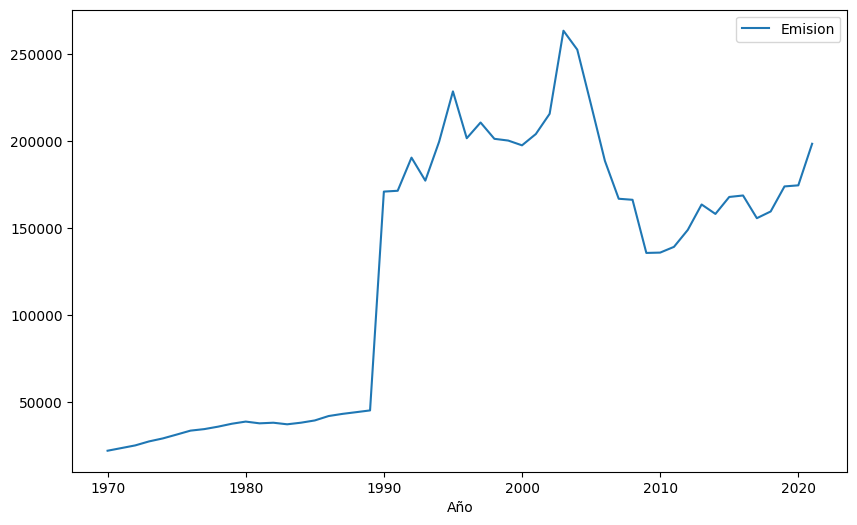

In [177]:
emisiones_por_año.groupby('Año').mean(numeric_only=True).plot(figsize=(10,6));

In [178]:
emisiones_por_año.groupby('Año').mean(numeric_only=True).idxmax()

,0
Emision,2003


In [179]:
emisiones_por_año.groupby(['Año','Gás']).mean(numeric_only=True)

Emision
Año  Gás                     
1970 C2F6 (t)        0.232610
     CF4 (t)         3.557421
     CH4 (t)      1471.024024
     CO (t)       2155.556658
     CO2 (t)     19244.913199
...                       ...
2021 HFC-23 (t)      0.000000
     HFC-32 (t)    261.100000
     N2O (t)       119.295311
     NOx (t)       679.395431
     SF6 (t)         5.240000

[1196 rows x 1 columns]

In [180]:
promedio_anual=emisiones_por_año.groupby(['Año','Gás']).mean(numeric_only=True).reset_index()
promedio_anual

,Año,Gás,Emision
0,1970,C2F6 (t),0.232610
1,1970,CF4 (t),3.557421
2,1970,CH4 (t),1471.024024
3,1970,CO (t),2155.556658
4,1970,CO2 (t),19244.913199
...,...,...,...
1191,2021,HFC-23 (t),0.000000
1192,2021,HFC-32 (t),261.100000
1193,2021,N2O (t),119.295311
1194,2021,NOx (t),679.395431


Así como el método melt() se utiliza para convertir una tabla del formato wide para long en pandas, también existe un método en esta biblioteca que puede convertir de formato long para wide, llamado pivot_table().

In [181]:
promedio_anual=promedio_anual.pivot_table(index='Año', columns='Gás', values='Emision')
promedio_anual

Gás,C2F6 (t),CF4 (t),CH4 (t),CO (t),CO2 (t),CO2e (t) GTP-AR2,CO2e (t) GTP-AR4,CO2e (t) GTP-AR5,CO2e (t) GTP-AR6,CO2e (t) GWP-AR2,...,COVNM (t),HFC-125 (t),HFC-134a (t),HFC-143a (t),HFC-152a (t),HFC-23 (t),HFC-32 (t),N2O (t),NOx (t),SF6 (t)
Año,,,,,,,,,,,,,,,,,,,,,
1970,0.232610,3.557421,1471.024024,2155.556658,19244.913199,20821.379814,20821.379814,19162.726020,19775.283385,35396.183865,...,742.074863,0.000000,0.000000,0.000000,0.0,0.00,0.00,31.632709,154.072797,0.000
1971,0.334611,5.117360,1525.506914,2259.625805,21598.587743,22466.288595,22466.288595,20748.481445,21386.175802,37570.982886,...,730.119047,0.000000,0.000000,0.000000,0.0,0.00,0.00,32.609237,170.550178,0.000
1972,0.404684,6.189025,1584.719568,2418.944795,23664.445521,24100.305265,24100.305265,22303.224240,22966.797327,39800.768350,...,774.278817,0.000000,0.000000,0.000000,0.0,0.00,0.00,34.311864,188.856161,0.000
1973,0.463147,7.083136,1642.612439,2596.053853,27726.668829,26683.827206,26683.827206,24827.077028,25516.409611,42947.755490,...,796.866394,0.000000,0.000000,0.000000,0.0,0.00,0.00,35.278689,217.320480,0.000
1974,0.471026,7.203619,1704.614365,2681.450599,30155.918952,28539.318732,28539.318732,26600.481407,27321.124852,45431.240064,...,1024.694923,0.000000,0.000000,0.000000,0.0,0.00,0.00,37.098183,247.521415,0.000
1975,0.502952,7.691893,1854.360821,2730.894830,32292.965771,30593.767465,30593.767465,28507.669059,29285.642221,48944.729581,...,1065.682750,0.000000,0.000000,0.000000,0.0,0.00,0.00,39.451008,262.716346,0.000
1976,0.577172,8.826970,1932.641716,2702.494362,35640.344723,33066.878007,33066.878007,30879.481709,31693.226162,52203.028009,...,1091.778909,0.000000,0.000000,0.000000,0.0,0.00,0.00,41.583225,287.013048,0.000
1977,0.692855,10.596169,1931.897645,2675.992077,37313.909077,34182.312333,34182.312333,31967.243034,32784.131397,53333.605735,...,1147.712448,0.000000,0.000000,0.000000,0.0,0.00,0.00,42.571086,292.405821,0.000
1978,0.749660,11.464915,1921.281930,2755.891877,40669.820049,35969.633601,35969.633601,33762.778999,34580.720998,55015.291182,...,1289.853564,0.000000,0.000000,0.000000,0.0,0.00,0.00,42.426649,322.982906,0.000


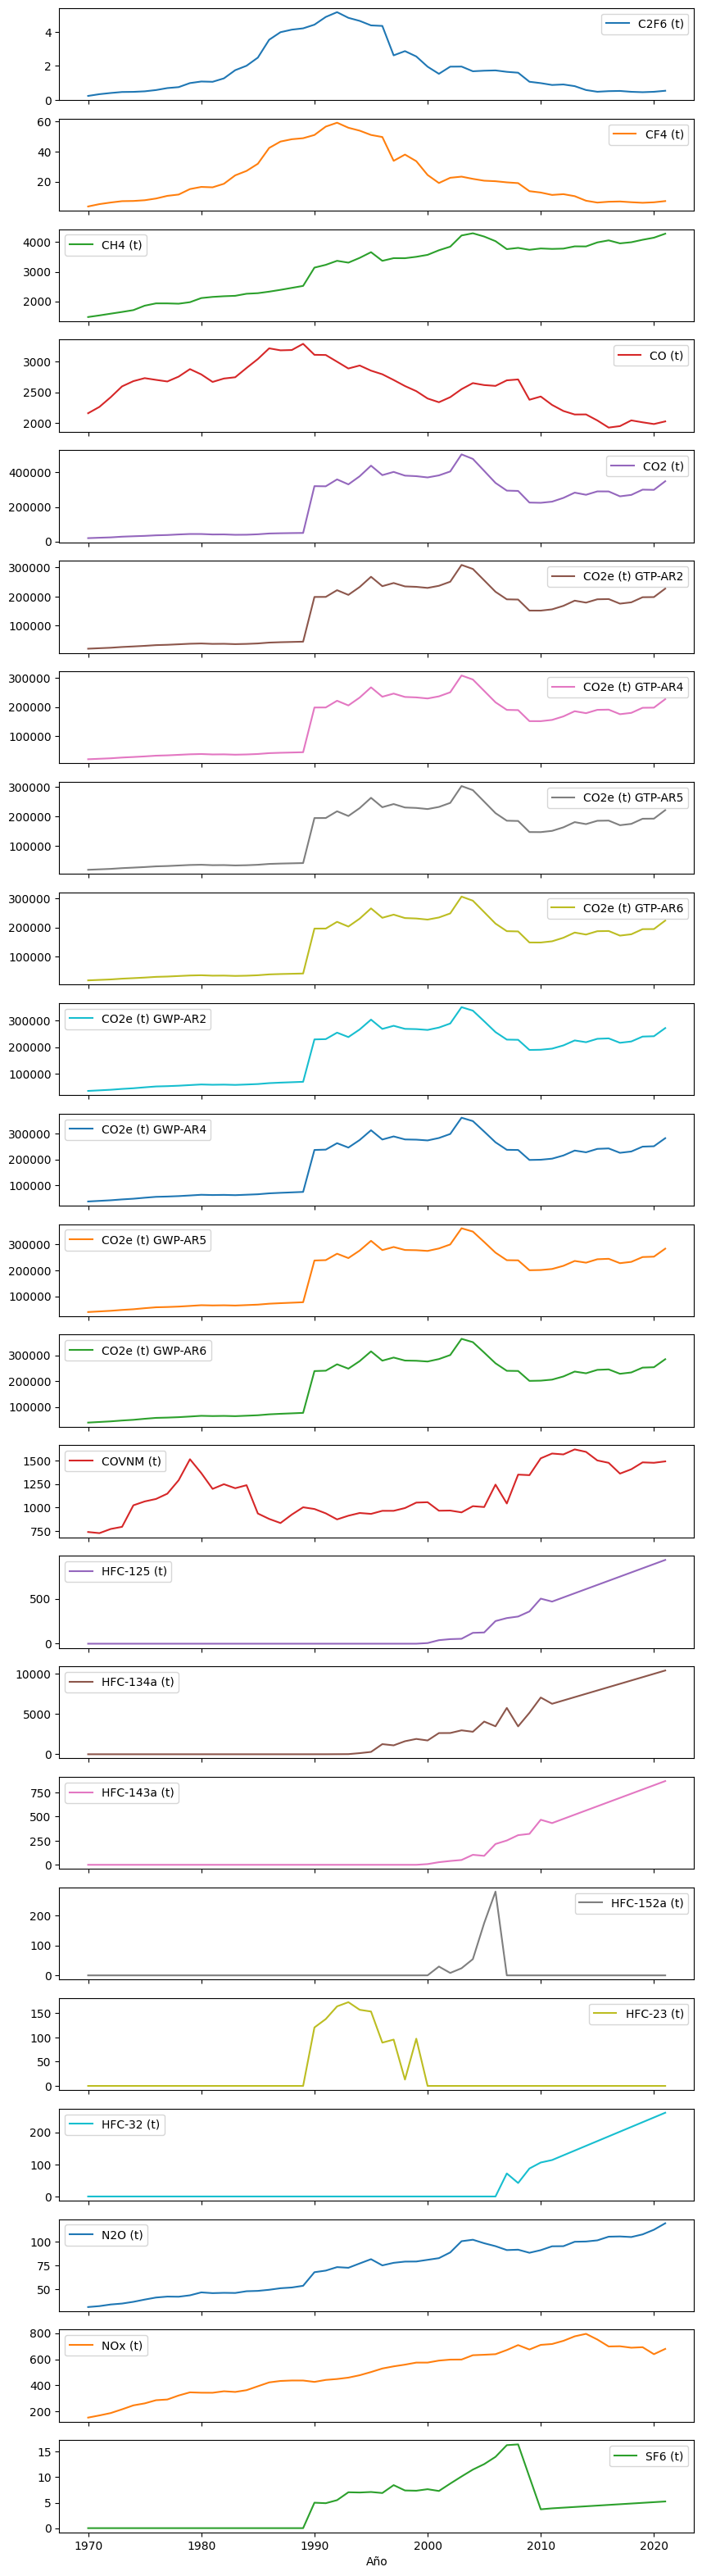

In [182]:
promedio_anual.plot(subplots=True,figsize=(10,40));

Subimos nuestro nuevo data frame ignorando el encabezado y las 34 filas de informacion s¿restante que no necesitamos

In [183]:
poblacion_estados=pd.read_excel('POP2022_Municipios.xls',header=1,skipfooter=34)
poblacion_estados

,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,POPULAÇÃO
0,RO,11,15,Alta Floresta D'Oeste,21558
1,RO,11,23,Ariquemes,100896
2,RO,11,31,Cabixi,5107
3,RO,11,49,Cacoal,92202
4,RO,11,56,Cerejeiras,15237
...,...,...,...,...,...
5565,GO,52,22005,Vianópolis,14046
5566,GO,52,22054,Vicentinópolis,8776
5567,GO,52,22203,Vila Boa,3686
5568,GO,52,22302,Vila Propício,5646


In [184]:
poblacion_estados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5570 entries, 0 to 5569
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   UF                 5570 non-null   object
 1   COD. UF            5570 non-null   int64 
 2   COD. MUNIC         5570 non-null   int64 
 3   NOME DO MUNICÍPIO  5570 non-null   object
 4   POPULAÇÃO          5570 non-null   object
dtypes: int64(2), object(3)
memory usage: 217.7+ KB


vemos que poblacion esta en formato objeto

In [185]:
#poblacion_estados['POPULAÇÃO'].astype(int)

vemos que hay filas con numeros y parentesis, es por eso que no o puede tomar como entero, vamos a buscar cuantas filas son asi

In [186]:
poblacion_estados[poblacion_estados['POPULAÇÃO'].str.contains('\(', na=False)]

<>:1: SyntaxWarning: invalid escape sequence '\('
<>:1: SyntaxWarning: invalid escape sequence '\('
/tmp/ipython-input-555682777.py:1: SyntaxWarning: invalid escape sequence '\('
  poblacion_estados[poblacion_estados['POPULAÇÃO'].str.contains('\(', na=False)]


,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,POPULAÇÃO
16,RO,11,205,Porto Velho,461.748(1)
74,AM,13,29,Alvarães,15.916(2)
81,AM,13,409,Barcelos,18.399(3)
83,AM,13,607,Benjamin Constant,37.436(4)
87,AM,13,805,Borba,33.209(5)
88,AM,13,839,Caapiranga,13.851(6)
97,AM,13,1605,Fonte Boa,27.692(7)
98,AM,13,1654,Guajará,13.809(8)
99,AM,13,1704,Humaitá,59.504(9)
103,AM,13,1951,Itamarati,10.783(10)


vamos a crear una nueva columna con los valores remplazando el parentesis y su contenido por nada con ayuda de regex

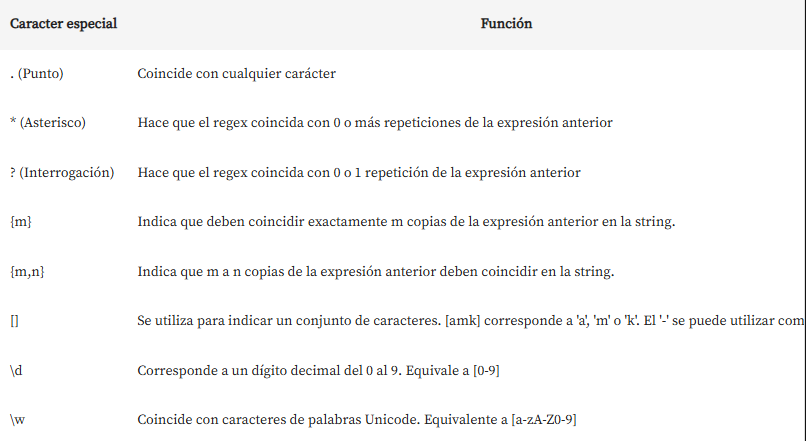

In [187]:
poblacion_estados=poblacion_estados.assign(poblacion_sinparentesis=poblacion_estados['POPULAÇÃO'].replace('\(\d{1,2}\)','',regex=True),
                         poblacion=lambda x: x.loc[:,'poblacion_sinparentesis'].replace('\.','',regex=True))
poblacion_estados

<>:1: SyntaxWarning: invalid escape sequence '\('
<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\('
<>:2: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipython-input-2325195739.py:1: SyntaxWarning: invalid escape sequence '\('
  poblacion_estados=poblacion_estados.assign(poblacion_sinparentesis=poblacion_estados['POPULAÇÃO'].replace('\(\d{1,2}\)','',regex=True),
/tmp/ipython-input-2325195739.py:2: SyntaxWarning: invalid escape sequence '\.'
  poblacion=lambda x: x.loc[:,'poblacion_sinparentesis'].replace('\.','',regex=True))


,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,POPULAÇÃO,poblacion_sinparentesis,poblacion
0,RO,11,15,Alta Floresta D'Oeste,21558,21558,21558
1,RO,11,23,Ariquemes,100896,100896,100896
2,RO,11,31,Cabixi,5107,5107,5107
3,RO,11,49,Cacoal,92202,92202,92202
4,RO,11,56,Cerejeiras,15237,15237,15237
...,...,...,...,...,...,...,...
5565,GO,52,22005,Vianópolis,14046,14046,14046
5566,GO,52,22054,Vicentinópolis,8776,8776,8776
5567,GO,52,22203,Vila Boa,3686,3686,3686
5568,GO,52,22302,Vila Propício,5646,5646,5646


In [188]:
poblacion_estados[poblacion_estados['POPULAÇÃO'].str.contains('\(', na=False)]

<>:1: SyntaxWarning: invalid escape sequence '\('
<>:1: SyntaxWarning: invalid escape sequence '\('
/tmp/ipython-input-555682777.py:1: SyntaxWarning: invalid escape sequence '\('
  poblacion_estados[poblacion_estados['POPULAÇÃO'].str.contains('\(', na=False)]


,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,POPULAÇÃO,poblacion_sinparentesis,poblacion
16,RO,11,205,Porto Velho,461.748(1),461.748,461748
74,AM,13,29,Alvarães,15.916(2),15.916,15916
81,AM,13,409,Barcelos,18.399(3),18.399,18399
83,AM,13,607,Benjamin Constant,37.436(4),37.436,37436
87,AM,13,805,Borba,33.209(5),33.209,33209
88,AM,13,839,Caapiranga,13.851(6),13.851,13851
97,AM,13,1605,Fonte Boa,27.692(7),27.692,27692
98,AM,13,1654,Guajará,13.809(8),13.809,13809
99,AM,13,1704,Humaitá,59.504(9),59.504,59504
103,AM,13,1951,Itamarati,10.783(10),10.783,10783


In [193]:
poblacion_estados=poblacion_estados.astype({'poblacion':'int64'})

In [194]:
poblacion_estados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5570 entries, 0 to 5569
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   UF                       5570 non-null   object
 1   COD. UF                  5570 non-null   int64 
 2   COD. MUNIC               5570 non-null   int64 
 3   NOME DO MUNICÍPIO        5570 non-null   object
 4   POPULAÇÃO                5570 non-null   object
 5   poblacion_sinparentesis  5570 non-null   object
 6   poblacion                5570 non-null   int64 
dtypes: int64(3), object(4)
memory usage: 304.7+ KB


In [195]:
poblacion_por_estado=poblacion_estados.groupby('UF')[['poblacion']].sum().reset_index()
poblacion_por_estado

,UF,poblacion
0,AC,829780
1,AL,3125254
2,AM,3952262
3,AP,774268
4,BA,14659023
5,CE,8936431
6,DF,2923369
7,ES,3975100
8,GO,6950976
9,MA,6800605


##Uniendo los datos
Vamos a utilizar el metodo merge para unir las tablas de emisiones por estado con la poblacion por estado

Hay tres métodos principales para unir DataFrame en pandas: concat, join y merge.

Concatenación (concat)

La concatenación es un método simple para combinar DataFrames, en el que sus columnas e índices se mantienen y los valores simplemente se concatenan uno encima del otro. El método concat() permite concatenar DataFrames verticalmente(uno encima del otro) u horizontalmente(uno al lado del otro).

La sintaxis básica para utilizar el método concat es la siguiente:

pd.concat([dataframe1, dataframe2, ...], axis=0/1)

En el cual, axis es el eje a partir del cual se producirá la concatenación. Si axis=0, la concatenación se produce a lo largo del eje vertical(apilamiento). Si axis=1, la concatenación se produce a lo largo del eje horizontal(uno al lado del otro).

Join

El método join se utiliza para unir dos DataFrames según sus columnas de índice o una columna de nombre especificada. Se puede utilizar para unir DataFrames con la misma o diferentes columnas.

Los dos DataFrames deben tener una columna con un nombre común o tener índices que contengan el mismo tipo de información, si la unión se da a través del índice y no utilizando ninguna columna. La sintaxis básica para utilizar el método de unión es la siguiente:

dataframe1.join(dataframe2, on='nome_coluna', how='left')

Donde on es el nombre de la columna en común entre los dos DataFrames utilizados como clave de unión. Si no se utiliza ningún valor, la unión se realizará en función de los índices del DataFrame. El parámetro how es el tipo de unión a realizar, que puede ser 'left', 'right', 'inner', 'outer'.

Merge

El método merge es el método más completo para unir dos DataFrames en función de sus índices o columnas de enlace. La sintaxis básica para utilizar el método merge es la siguiente:

dataframe1.merge(dataframe2, on=None, how='inner', left_on='nombre_columna_dataframe1', right_on='nombre_columna_dataframe2')

Donde on es el nombre de la columna en ambos DataFrames, en caso sea el mismo nombre. El parámetro how es el tipo de unión a realizar, que puede ser 'left', 'right', 'inner', 'outer'. Los parámetros left_on y right_on son respectivamente los nombres de las columnas del DataFrame1 y DataFrame2, en caso tengan nombres diferentes.

In [197]:
emisiones_estados=emisiones_por_año[emisiones_por_año['Año']==2021].groupby('Estado')[['Emision']].sum().reset_index()
emisiones_estados

,Estado,Emision
0,AC,3.505471e+08
1,AL,6.261279e+07
2,AM,1.189649e+09
3,AP,3.568410e+07
4,BA,5.932251e+08
5,CE,2.034731e+08
6,DF,5.668738e+07
7,ES,2.697547e+08
8,GO,6.008081e+08
9,MA,9.476324e+08


In [198]:
datos_agrupados=pd.merge(emisiones_estados,poblacion_por_estado,left_on='Estado',right_on='UF')
datos_agrupados

,Estado,Emision,UF,poblacion
0,AC,3.505471e+08,AC,829780
1,AL,6.261279e+07,AL,3125254
2,AM,1.189649e+09,AM,3952262
3,AP,3.568410e+07,AP,774268
4,BA,5.932251e+08,BA,14659023
5,CE,2.034731e+08,CE,8936431
6,DF,5.668738e+07,DF,2923369
7,ES,2.697547e+08,ES,3975100
8,GO,6.008081e+08,GO,6950976
9,MA,9.476324e+08,MA,6800605


vamos a ver si hay relacion entre la cantidad de poblacion y las emisiones por estado

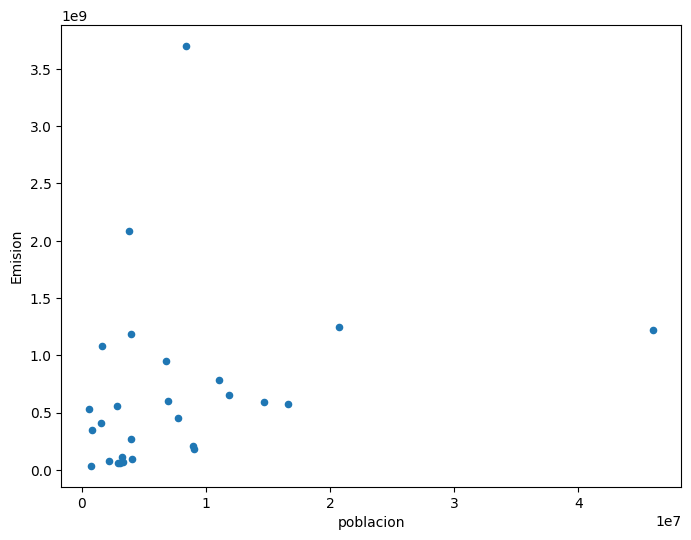

In [201]:
datos_agrupados.plot(x='poblacion', y ='Emision',kind='scatter',figsize=(8,6));

In [203]:
import plotly.express as px

In [204]:
px.scatter(data_frame=datos_agrupados,x='poblacion', y ='Emision',text='Estado',opacity=0)

vamos a crear una nueva columna con las emisiones per capita

In [205]:
datos_agrupados=datos_agrupados.assign(emision_per_capita=datos_agrupados['Emision']/datos_agrupados['poblacion']).sort_values('emision_per_capita',ascending=False)
datos_agrupados

,Estado,Emision,UF,poblacion,emision_per_capita
21,RR,5.282071e+08,RR,634805,832.077694
20,RO,1.083515e+09,RO,1616379,670.334662
12,MT,2.081610e+09,MT,3784239,550.073647
13,PA,3.701684e+09,PA,8442962,438.434230
0,AC,3.505471e+08,AC,829780,422.457928
2,AM,1.189649e+09,AM,3952262,301.004463
26,TO,4.082159e+08,TO,1584306,257.662300
11,MS,5.551278e+08,MS,2833742,195.899220
9,MA,9.476324e+08,MA,6800605,139.345312
8,GO,6.008081e+08,GO,6950976,86.435075


In [206]:
px.bar(data_frame=datos_agrupados, x='Estado',y='emision_per_capita')

In [207]:
px.scatter(data_frame=datos_agrupados,x='poblacion', y ='Emision',text='Estado',size='emision_per_capita')